# Analisis Komparatif Metode Deteksi dan Strategi Penanganan Outlier
### Kelompok 8 - Tugas Besar Data Mining (IF3024) — Semester Genap 2025/2026
---
Notebook ini berisi implementasi **source code** lengkap dan bersih untuk melakukan eksperimen komparasi 3 metode deteksi outlier (IQR, Z-Score, Isolation Forest) dan 3 strategi penanganan (Removal, Capping, Log Transform) pada **Online Shoppers Purchasing Intention Dataset**.

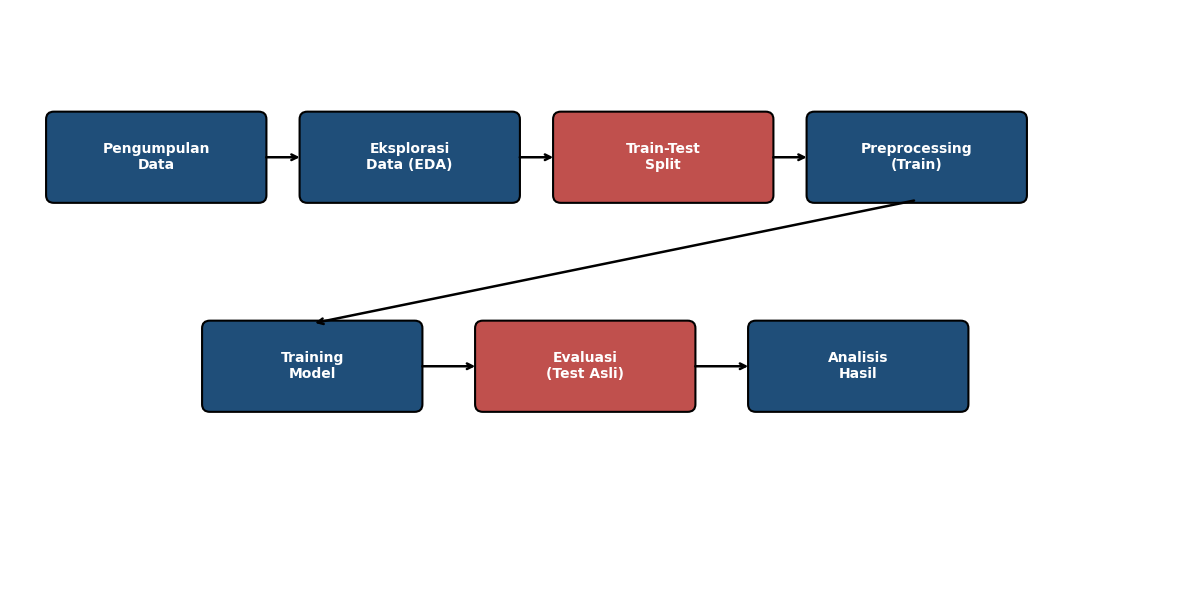

In [1]:
# ==========================================================
# VISUALISASI ALUR PENELITIAN (FLOWCHART)
# ==========================================================
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch

fig, ax = plt.subplots(figsize=(12, 6))
ax.set_xlim(0, 12)
ax.set_ylim(0, 6)
ax.axis('off')

def add_box(x, y, w, h, text, color):
    box = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.03,rounding_size=0.08",
        linewidth=1.5,
        edgecolor='black',
        facecolor=color
    )
    ax.add_patch(box)
    ax.text(
        x + w/2, y + h/2, text,
        ha='center', va='center',
        fontsize=10, fontweight='bold', color='white'
    )

def add_arrow(x1, y1, x2, y2):
    ax.annotate(
        '',
        xy=(x2, y2), xytext=(x1, y1),
        arrowprops=dict(arrowstyle='->', lw=1.8, color='black')
    )

w, h = 2.2, 0.9

# Baris atas
top_steps = [
    (0.4, 4.0, "Pengumpulan\nData", "#1f4e79"),
    (3.0, 4.0, "Eksplorasi\nData (EDA)", "#1f4e79"),
    (5.6, 4.0, "Train-Test\nSplit", "#c0504d"),
    (8.2, 4.0, "Preprocessing\n(Train)", "#1f4e79"),
]

# Baris bawah
bottom_steps = [
    (2.0, 1.8, "Training\nModel", "#1f4e79"),
    (4.8, 1.8, "Evaluasi\n(Test Asli)", "#c0504d"),
    (7.6, 1.8, "Analisis\nHasil", "#1f4e79"),
]

# Gambar box
for x, y, label, color in top_steps:
    add_box(x, y, w, h, label, color)

for x, y, label, color in bottom_steps:
    add_box(x, y, w, h, label, color)

# Panah baris atas
for i in range(len(top_steps) - 1):
    add_arrow(
        top_steps[i][0] + w, top_steps[i][1] + h/2,
        top_steps[i+1][0], top_steps[i+1][1] + h/2
    )

# Panah turun dari Preprocessing ke Training
add_arrow(
    top_steps[-1][0] + w/2, top_steps[-1][1],
    bottom_steps[0][0] + w/2, bottom_steps[0][1] + h
)

# Panah baris bawah
for i in range(len(bottom_steps) - 1):
    add_arrow(
        bottom_steps[i][0] + w, bottom_steps[i][1] + h/2,
        bottom_steps[i+1][0], bottom_steps[i+1][1] + h/2
    )

plt.tight_layout()
plt.savefig("flowchart_penelitian_vertikal.png", dpi=300, bbox_inches='tight')
plt.show()

In [2]:
# ==========================================================
# 1. IMPORT LIBRARIES & SETUP ENVIRONMENT
# ==========================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os

# Scikit-learn preprocessing & models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import IsolationForest, RandomForestClassifier

# Scikit-learn metrics
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    confusion_matrix
)

# Configure styling
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

In [3]:
# ==========================================================
# 2. LOAD DATASET (LOCAL CSV WITH UCI FALLBACK)
# ==========================================================
csv_filename = 'online_shoppers_intention.csv'
df = None

# Try loading locally
if os.path.exists(csv_filename):
    print(f"✅ Loading dataset locally from: {csv_filename}")
    df = pd.read_csv(csv_filename)
else:
    print("🌐 Local CSV not found. Fetching from UCI Machine Learning Repository...")
    try:
        from ucimlrepo import fetch_ucirepo
        dataset = fetch_ucirepo(id=468)
        df = pd.concat([dataset.data.features, dataset.data.targets], axis=1)
        # Save to CSV for local persistence
        df.to_csv(csv_filename, index=False)
        print(f"✅ Dataset fetched and saved locally as: {csv_filename}")
    except Exception as e:
        print(f"❌ Failed to fetch dataset: {e}")
        print("Please ensure online_shoppers_intention.csv is in the workspace.")

if df is not None:
    print(f"\n📊 Dataset info: {df.shape[0]} baris, {df.shape[1]} kolom")
    
    # Menghapus duplikat
    duplicate_count = df.duplicated().sum()
    if duplicate_count > 0:
        df = df.drop_duplicates()
        print(f"🗑️ Menghapus {duplicate_count} baris data duplikat. Sisa data: {df.shape[0]} baris.")
    
    # Missing values check
    missing_count = df.isnull().sum().sum()
    print(f"🔍 Total missing values: {missing_count}")
    
    # Descriptive statistics
    numeric_cols = ['Administrative', 'Administrative_Duration', 'Informational',
                    'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
                    'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']
    stats_df = pd.DataFrame({
        'Mean': df[numeric_cols].mean(),
        'Std': df[numeric_cols].std(),
        'Min': df[numeric_cols].min(),
        'Median': df[numeric_cols].median(),
        'Max': df[numeric_cols].max(),
        'Skewness': df[numeric_cols].skew()
    })
    print("\n📈 Statistik Deskriptif Fitur Numerik:")
    display(stats_df.round(3))

✅ Loading dataset locally from: online_shoppers_intention.csv

📊 Dataset info: 12330 baris, 18 kolom
🗑️ Menghapus 125 baris data duplikat. Sisa data: 12205 baris.
🔍 Total missing values: 0

📈 Statistik Deskriptif Fitur Numerik:


,Mean,Std,Min,Median,Max,Skewness
Administrative,2.339,3.330,0.0,1.000,27.000,1.947
Administrative_Duration,81.646,177.492,0.0,9.000,3398.750,5.592
Informational,0.509,1.276,0.0,0.000,24.000,4.014
Informational_Duration,34.825,141.425,0.0,0.000,2549.375,7.540
ProductRelated,32.046,44.594,0.0,18.000,705.000,4.333
ProductRelated_Duration,1206.982,1919.601,0.0,608.943,63973.522,7.253
BounceRates,0.020,0.045,0.0,0.003,0.200,3.162
ExitRates,0.041,0.046,0.0,0.025,0.200,2.235
PageValues,5.950,18.654,0.0,0.000,361.764,6.351
SpecialDay,0.062,0.200,0.0,0.000,1.000,3.286


In [4]:
# ==========================================================
# 3. CATEGORICAL ENCODING & TRAIN-TEST SPLIT
# ==========================================================
# Encoding Month and VisitorType, converting boolean Weekend and Revenue to int
df_enc = df.copy()
for col in ['Month', 'VisitorType']:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])

df_enc['Weekend'] = df_enc['Weekend'].astype(int)
df_enc['Revenue'] = df_enc['Revenue'].astype(int)

X = df_enc.drop('Revenue', axis=1)
y = df_enc['Revenue']

# Split data - STRATIFY to maintain class balance
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Data Latih (Train Set): {X_train.shape[0]} sampel (Revenue=True: {y_train.sum()}, {y_train.mean()*100:.2f}%)")
print(f"✅ Data Uji (Test Set):     {X_test.shape[0]} sampel (Revenue=True: {y_test.sum()}, {y_test.mean()*100:.2f}%)")

✅ Data Latih (Train Set): 9764 sampel (Revenue=True: 1526, 15.63%)
✅ Data Uji (Test Set):     2441 sampel (Revenue=True: 382, 15.65%)


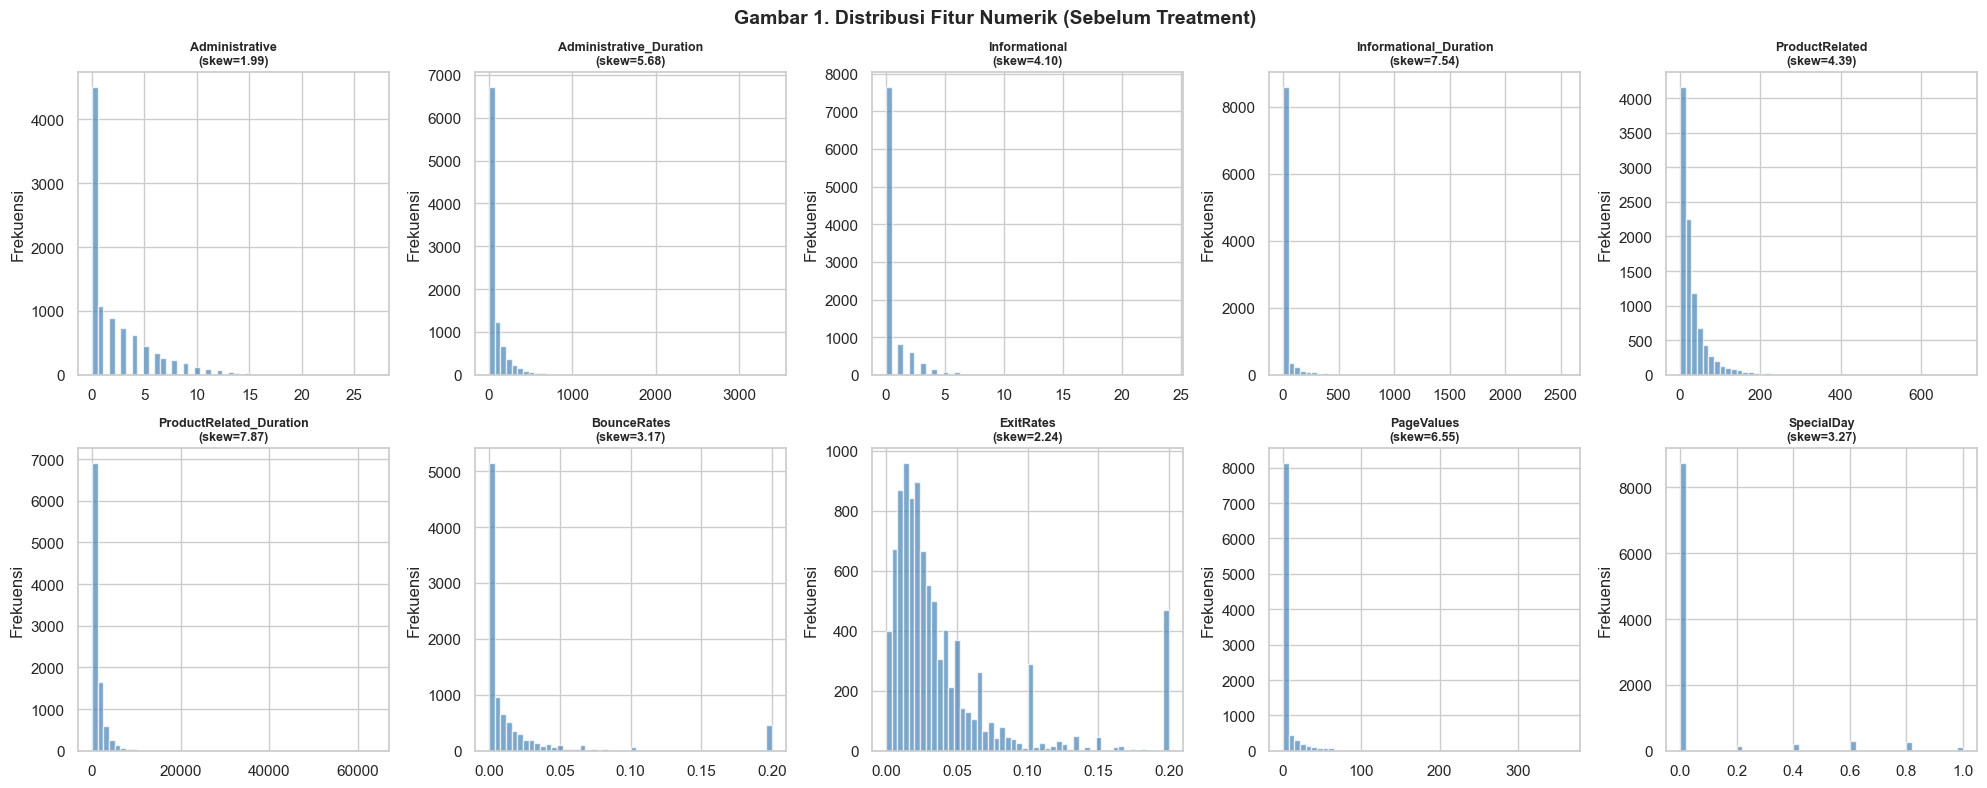

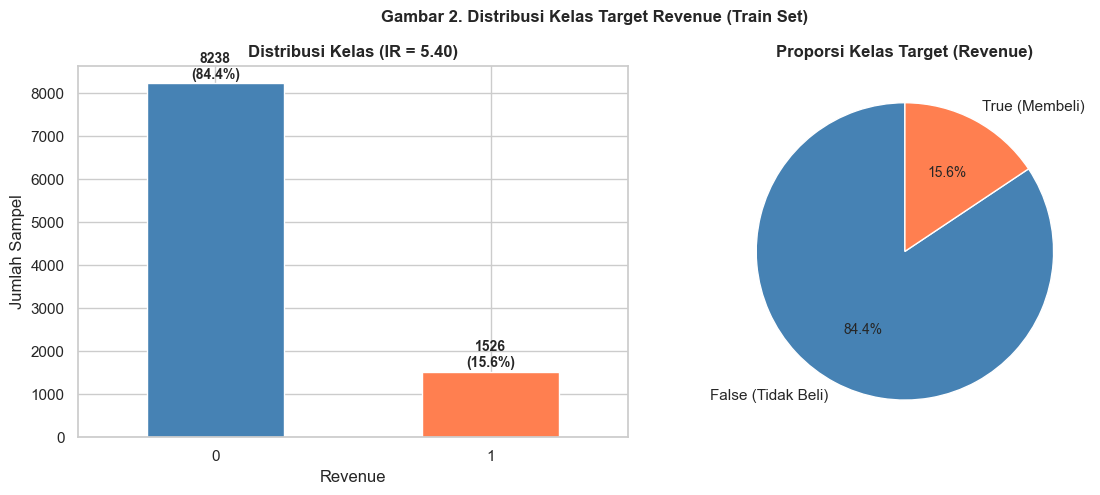

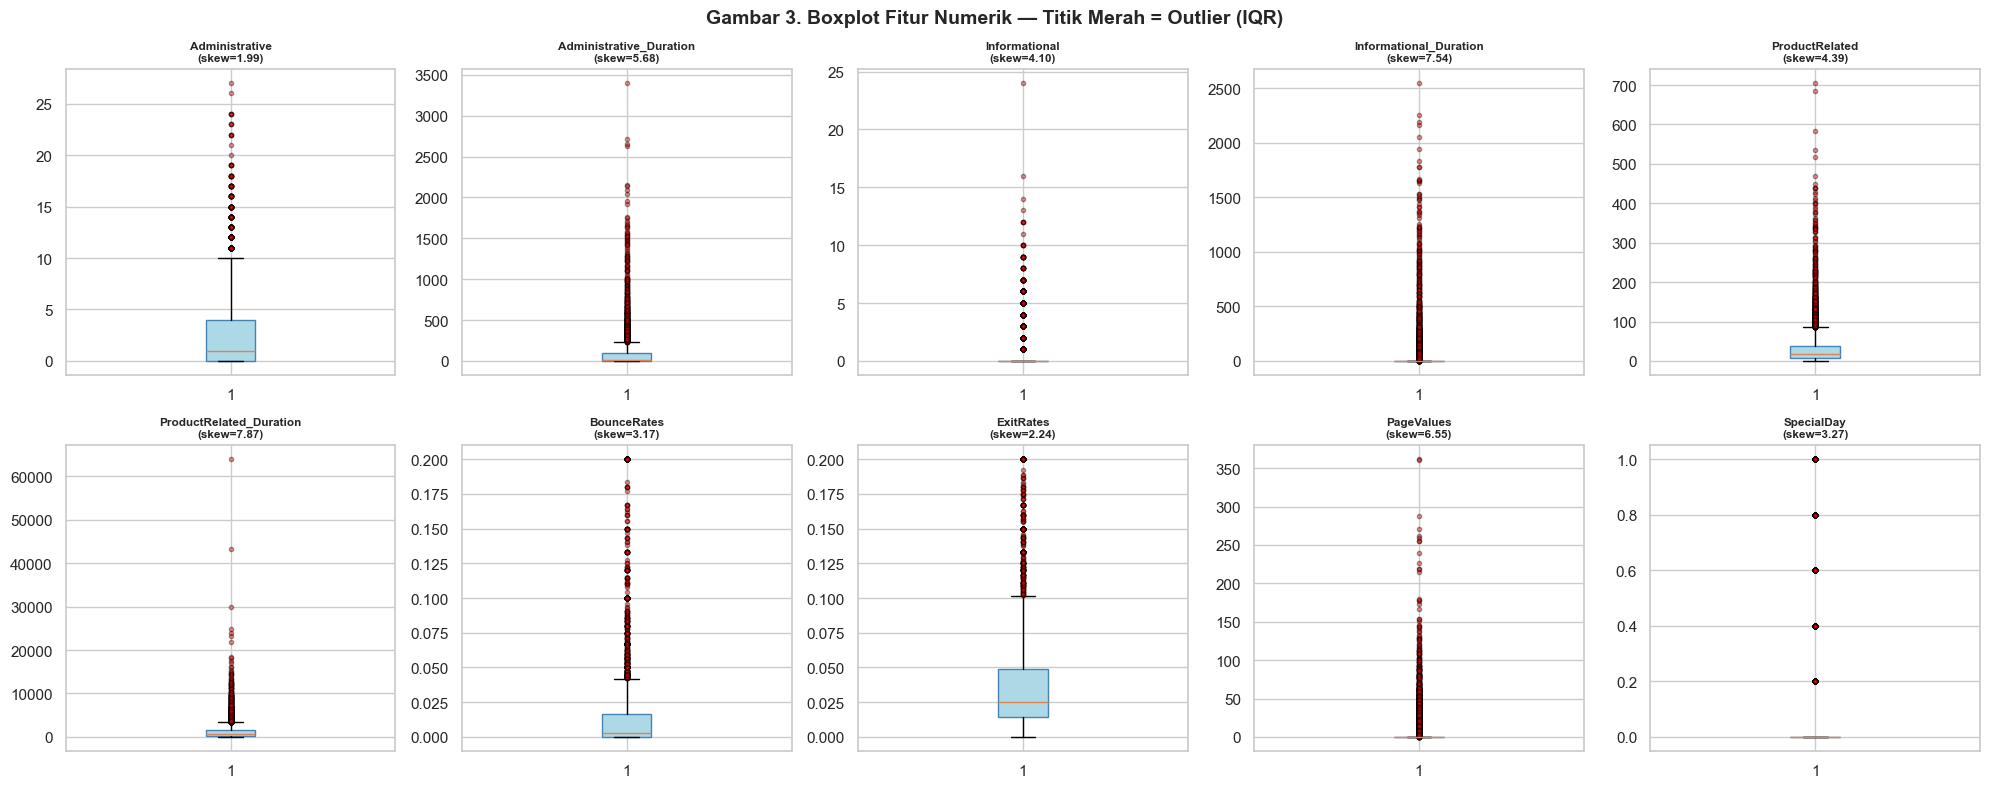

In [5]:
# ==========================================================
# 4. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================================
num_cols = ['Administrative', 'Administrative_Duration', 'Informational',
            'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
            'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay']

# 4.1 Histogram Distribusi Fitur
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].hist(X_train[col].dropna(), bins=50, alpha=0.7, color='steelblue', edgecolor='white')
    axes[i].set_title(f'{col}\n(skew={X_train[col].skew():.2f})', fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Frekuensi')
plt.suptitle('Gambar 1. Distribusi Fitur Numerik (Sebelum Treatment)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 4.2 Pie & Bar Chart Distribusi Kelas Target
target_counts = y_train.value_counts()
ir = target_counts.max() / target_counts.min()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
target_counts.plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'], edgecolor='white', rot=0)
axes[0].set_title(f'Distribusi Kelas (IR = {ir:.2f})', fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
for i, v in enumerate(target_counts):
    axes[0].text(i, v + 100, f'{v}\n({v/len(y_train)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].pie(target_counts, labels=['False (Tidak Beli)', 'True (Membeli)'],
            autopct='%1.1f%%', colors=['steelblue', 'coral'], startangle=90)
axes[1].set_title('Proporsi Kelas Target (Revenue)', fontweight='bold')
plt.suptitle('Gambar 2. Distribusi Kelas Target Revenue (Train Set)', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

# 4.3 Boxplot Deteksi Outlier
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    axes[i].boxplot(X_train[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='steelblue'),
                    flierprops=dict(marker='o', markerfacecolor='red',
                                   markersize=3, alpha=0.4))
    axes[i].set_title(f'{col}\n(skew={X_train[col].skew():.2f})', fontsize=8.5, fontweight='bold')
plt.suptitle('Gambar 3. Boxplot Fitur Numerik — Titik Merah = Outlier (IQR)', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.show()

In [6]:
# ==========================================================
# 5. DETAILED OUTLIER DETECTION STATS (TRAIN SET ONLY)
# ==========================================================
X_num = X_train[num_cols]

# 1. IQR Method
outlier_iqr_df = pd.DataFrame(index=X_num.index)
for col in num_cols:
    Q1, Q3 = X_num[col].quantile(0.25), X_num[col].quantile(0.75)
    IQR = Q3 - Q1
    outlier_iqr_df[col] = (X_num[col] < Q1 - 1.5*IQR) | (X_num[col] > Q3 + 1.5*IQR)
mask_iqr = outlier_iqr_df.any(axis=1)

# 2. Z-Score Method (|z| > 3)
z_scores = np.abs(stats.zscore(X_num.fillna(X_num.median())))
mask_zscore = (z_scores > 3).any(axis=1)

# 3. Isolation Forest Method (contamination=0.05)
scaler = StandardScaler()
X_sc = scaler.fit_transform(X_num.fillna(X_num.median()))
if_model = IsolationForest(contamination=0.05, random_state=42, n_estimators=100)
mask_if = if_model.fit_predict(X_sc) == -1

# Print Summary Table
summary = pd.DataFrame({
    'Metode Deteksi': ['IQR (1.5×IQR)', 'Z-Score (|z|>3)', 'Isolation Forest (cont=0.05)'],
    'Outlier Terdeteksi': [mask_iqr.sum(), mask_zscore.sum(), mask_if.sum()],
    'Persentase (%)': [f"{mask_iqr.mean()*100:.2f}%", f"{mask_zscore.mean()*100:.2f}%", f"{mask_if.mean()*100:.2f}%"],
    'Sisa Data (Latih)': [(~mask_iqr).sum(), (~mask_zscore).sum(), (~mask_if).sum()]
})
print("Tabel 1. Perbandingan Jumlah Outlier yang Terdeteksi:")
display(summary)

# IQR Detail Table
detail_rows = []
for col in num_cols:
    n_out = outlier_iqr_df[col].sum()
    if n_out > 0:
        Q1, Q3 = X_num[col].quantile(0.25), X_num[col].quantile(0.75)
        IQR = Q3 - Q1
        detail_rows.append({
            'Fitur': col,
            'Outlier (IQR)': n_out,
            'Persentase': f"{(n_out/len(X_num)*100):.2f}%",
            'Batas Atas Fence': round(Q3 + 1.5*IQR, 3),
            'Nilai Max': round(X_num[col].max(), 3)
        })
print("\nDetail Outlier per Fitur (Metode IQR):")
display(pd.DataFrame(detail_rows))

Tabel 1. Perbandingan Jumlah Outlier yang Terdeteksi:


,Metode Deteksi,Outlier Terdeteksi,Persentase (%),Sisa Data (Latih)
0,IQR (1.5×IQR),5548,56.82%,4216
1,Z-Score (|z|>3),1738,17.80%,8026
2,Isolation Forest (cont=0.05),489,5.01%,9275



Detail Outlier per Fitur (Metode IQR):


,Fitur,Outlier (IQR),Persentase,Batas Atas Fence,Nilai Max
0,Administrative,325,3.33%,10.000,27.000
1,Administrative_Duration,937,9.60%,236.812,3398.750
2,Informational,2107,21.58%,0.000,24.000
3,Informational_Duration,1917,19.63%,0.000,2549.375
4,ProductRelated,767,7.86%,85.500,705.000
5,ProductRelated_Duration,751,7.69%,3418.925,63973.522
6,BounceRates,1127,11.54%,0.042,0.200
7,ExitRates,780,7.99%,0.102,0.200
8,PageValues,2187,22.40%,0.000,361.764
9,SpecialDay,1008,10.32%,0.000,1.000


In [7]:
# ==========================================================
# 6. CONFIGURING THE 9 SCENARIOS (DETECTION & TREATMENT)
# ==========================================================
# We store the preprocessed (X_train_treated, y_train_treated) in a dictionary
scenarios = {}

# --- METODE DETEKSI 1: IQR ---
outlier_iqr = mask_iqr

# IQR + Removal
scenarios['IQR+Removal'] = (X_train[~outlier_iqr].copy(), y_train[~outlier_iqr].copy())

# IQR + Capping
X_capped_iqr = X_train.copy()
for col in num_cols:
    Q1, Q3 = X_train[col].quantile(0.25), X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    X_capped_iqr[col] = X_capped_iqr[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)
scenarios['IQR+Capping'] = (X_capped_iqr, y_train.copy())

# IQR + LogTransform
X_log_iqr = X_train.copy()
for col in num_cols:
    if (X_train[col] >= 0).all() and X_train[col].skew() > 0.5:
        X_log_iqr[col] = np.log1p(X_train[col])
scenarios['IQR+LogTransform'] = (X_log_iqr, y_train.copy())


# --- METODE DETEKSI 2: Z-Score ---
outlier_z = mask_zscore

# Z-Score + Removal
scenarios['Z-Score+Removal'] = (X_train[~outlier_z].copy(), y_train[~outlier_z].copy())

# Z-Score + Capping
X_capped_z = X_train.copy()
for col in num_cols:
    mean, std = X_train[col].mean(), X_train[col].std()
    X_capped_z[col] = X_capped_z[col].clip(lower=mean - 3*std, upper=mean + 3*std)
scenarios['Z-Score+Capping'] = (X_capped_z, y_train.copy())

# Z-Score + LogTransform
X_log_z = X_train.copy()
for col in num_cols:
    if (X_train[col] >= 0).all() and X_train[col].skew() > 0.5:
        X_log_z[col] = np.log1p(X_train[col])
scenarios['Z-Score+LogTransform'] = (X_log_z, y_train.copy())


# --- METODE DETEKSI 3: Isolation Forest ---
outlier_if = mask_if

# IsolationForest + Removal
scenarios['IsolationForest+Removal'] = (X_train[~outlier_if].copy(), y_train[~outlier_if].copy())

# IsolationForest + Capping (Robust capping at IQR fences)
X_capped_if = X_train.copy()
for col in num_cols:
    Q1, Q3 = X_train[col].quantile(0.25), X_train[col].quantile(0.75)
    IQR = Q3 - Q1
    X_capped_if[col] = X_capped_if[col].clip(lower=Q1 - 1.5*IQR, upper=Q3 + 1.5*IQR)
scenarios['IsolationForest+Capping'] = (X_capped_if, y_train.copy())

# IsolationForest + LogTransform
X_log_if = X_train.copy()
for col in num_cols:
    if (X_train[col] >= 0).all() and X_train[col].skew() > 0.5:
        X_log_if[col] = np.log1p(X_train[col])
scenarios['IsolationForest+LogTransform'] = (X_log_if, y_train.copy())

print("✅ Preprocessed training data generated for all 9 scenarios!")

✅ Preprocessed training data generated for all 9 scenarios!


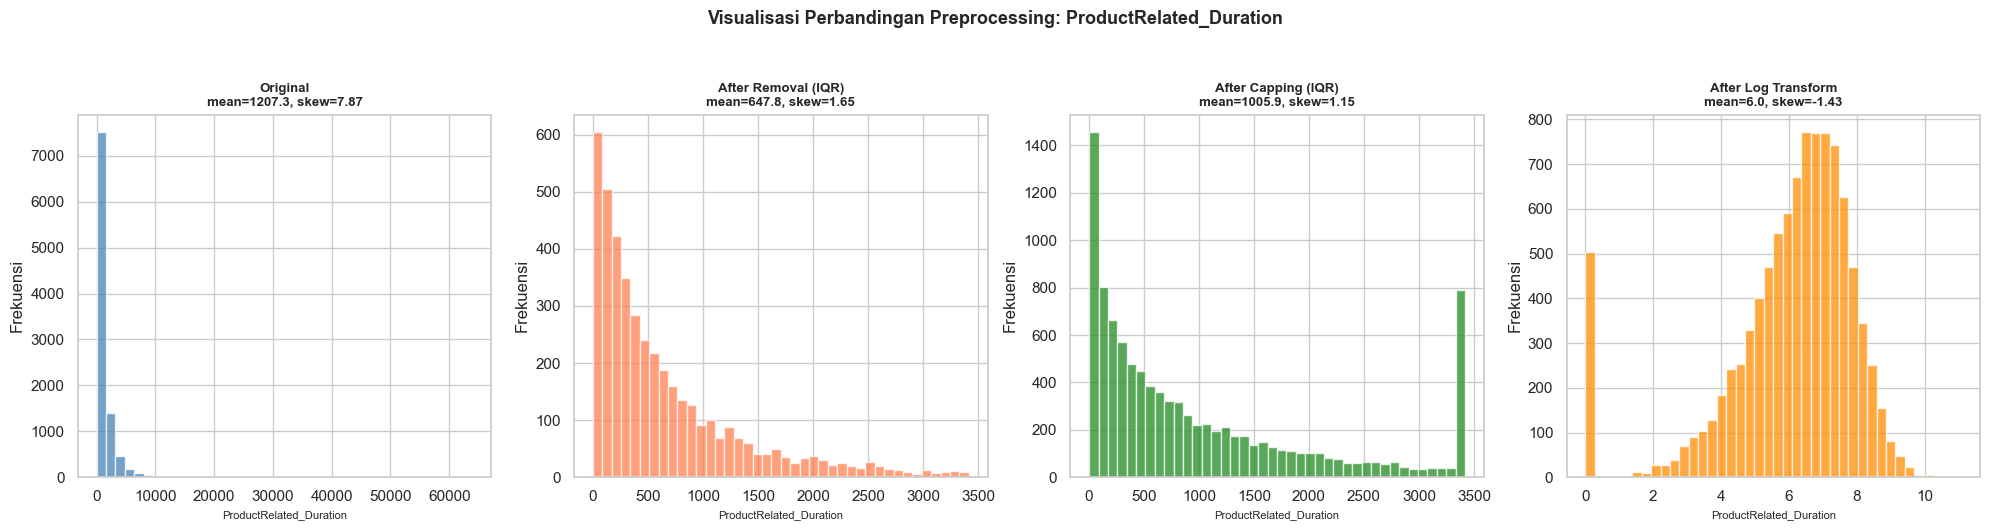

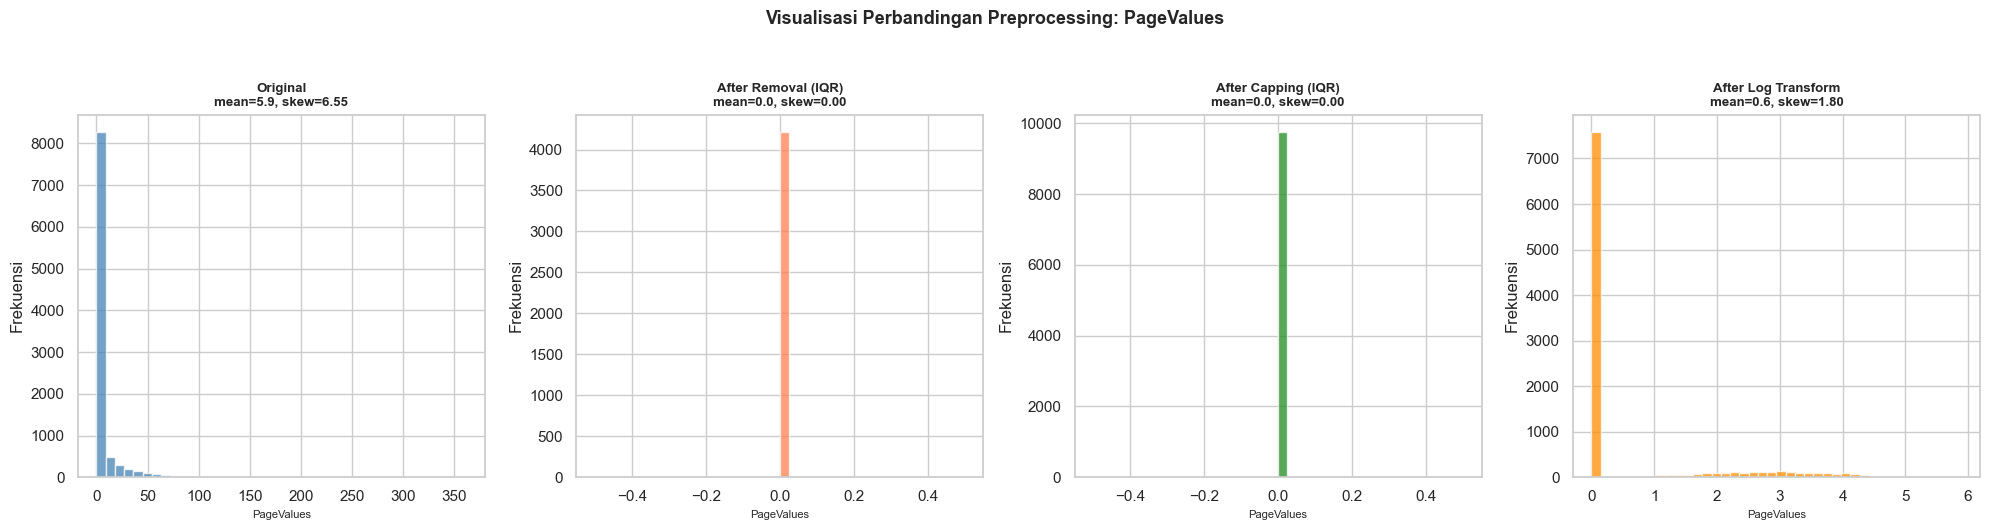

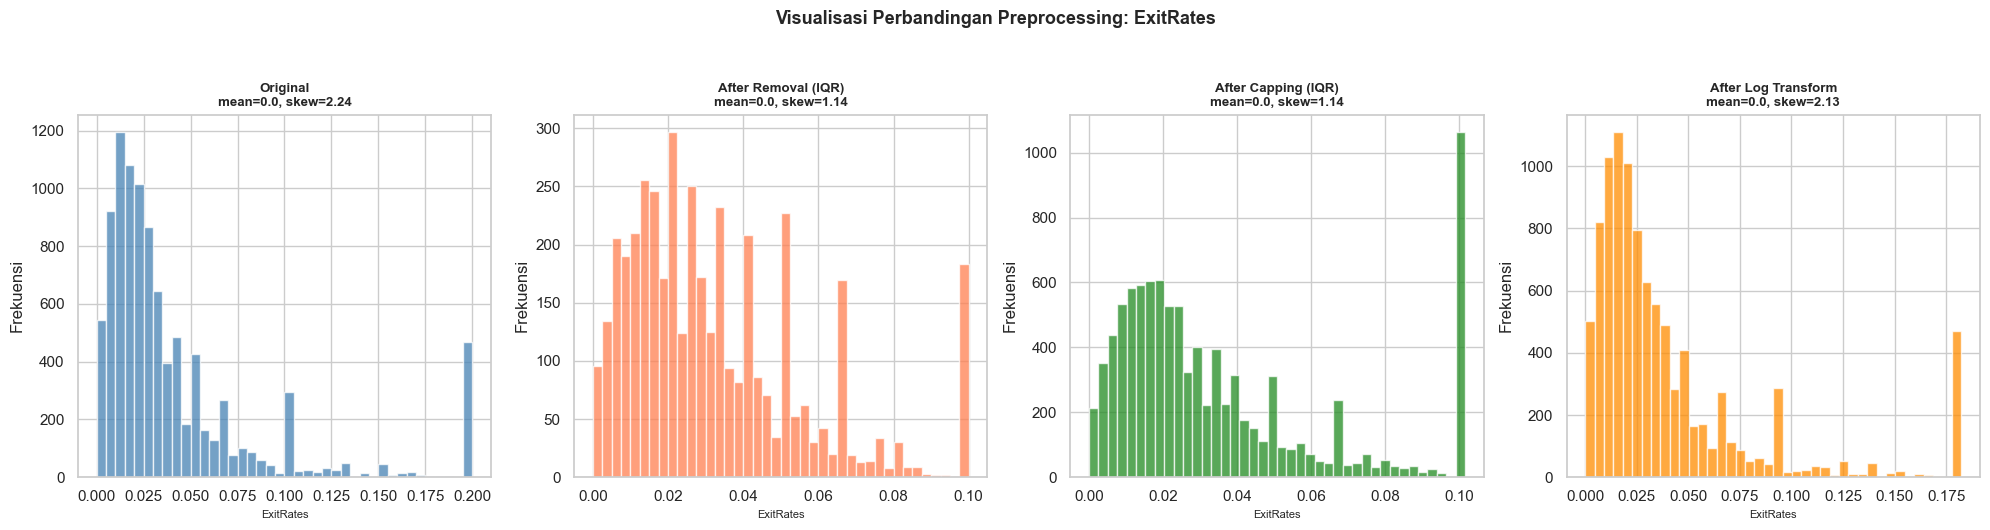

In [8]:
# ==========================================================
# 7. VISUALIZING TREATMENT EFFECTS (BEFORE AND AFTER)
# ==========================================================
target_cols = ['ProductRelated_Duration', 'PageValues', 'ExitRates']

for focus_col in target_cols:
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    
    # Configure distributions based on IQR treatment
    data_configs = [ 
        ('Original', X_train[focus_col], 'steelblue'),
        ('After Removal (IQR)', scenarios['IQR+Removal'][0][focus_col], 'coral'),
        ('After Capping (IQR)', scenarios['IQR+Capping'][0][focus_col], 'forestgreen'),
        ('After Log Transform', scenarios['IQR+LogTransform'][0][focus_col], 'darkorange')
    ]
    
    for ax, (label, data, color) in zip(axes, data_configs):
        ax.hist(data, bins=40, alpha=0.75, color=color, edgecolor='white')
        ax.set_title(f'{label}\nmean={data.mean():.1f}, skew={data.skew():.2f}', fontweight='bold', fontsize=9.5)
        ax.set_xlabel(focus_col, fontsize=8)
        ax.set_ylabel('Frekuensi')
        
    plt.suptitle(f'Visualisasi Perbandingan Preprocessing: {focus_col}', fontweight='bold', fontsize=13, y=1.05)
    plt.tight_layout()
    plt.show()

In [9]:
# ==========================================================
# 8. TRAINING AND EVALUATING THE 10 SCENARIOS
# ==========================================================
all_results = []

def evaluate_model(model, X_test_sc, y_test, name):
    y_pred = model.predict(X_test_sc)
    y_proba = model.predict_proba(X_test_sc)[:, 1]
    return {
        'Skenario': name,
        'Accuracy': round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, average='macro'), 4),
        'Recall': round(recall_score(y_test, y_pred, average='macro'), 4),
        'F1-Score': round(f1_score(y_test, y_pred, average='macro'), 4),
        'AUC-ROC': round(roc_auc_score(y_test, y_proba), 4)
    }

# --- 1. Skenario Baseline (No Outlier Preprocessing) ---
scaler_base = StandardScaler()
X_train_sc_base = scaler_base.fit_transform(X_train)
X_test_sc_base = scaler_base.transform(X_test)

model_base = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
model_base.fit(X_train_sc_base, y_train)
all_results.append(evaluate_model(model_base, X_test_sc_base, y_test, "Baseline (No Treatment)"))


# --- 2. Skenario 9 Kombinasi ---
for sc_name, (X_tr, y_tr) in scenarios.items():
    # Fit scaling on treated train set
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    
    # Process test set on-the-fly depending on scenario to avoid mismatch (CRITICAL BUG FIX!)
    X_te_processed = X_test.copy()
    if "LogTransform" in sc_name:
        for col in num_cols:
            if (X_train[col] >= 0).all() and X_train[col].skew() > 0.5:
                X_te_processed[col] = np.log1p(X_test[col])
                
    X_te_sc = scaler.transform(X_te_processed)
    
    # Train Random Forest Classifier
    model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    model.fit(X_tr_sc, y_tr)
    
    # Evaluate and store results
    result = evaluate_model(model, X_te_sc, y_test, sc_name)
    all_results.append(result)

# Display Results sorted by F1-Score (Macro)
df_results = pd.DataFrame(all_results).sort_values('F1-Score', ascending=False)
print("Hasil Akhir Performa Model untuk Setiap Skenario (Diurutkan berdasarkan F1-Score):")
print(df_results.to_string(index=False))

Hasil Akhir Performa Model untuk Setiap Skenario (Diurutkan berdasarkan F1-Score):
                    Skenario  Accuracy  Precision  Recall  F1-Score  AUC-ROC
             Z-Score+Capping    0.9009     0.8345  0.7589    0.7891   0.9262
            IQR+LogTransform    0.8984     0.8260  0.7585    0.7860   0.9240
IsolationForest+LogTransform    0.8984     0.8260  0.7585    0.7860   0.9240
        Z-Score+LogTransform    0.8984     0.8260  0.7585    0.7860   0.9240
     Baseline (No Treatment)    0.8980     0.8247  0.7583    0.7854   0.9241
     IsolationForest+Removal    0.8996     0.8332  0.7539    0.7851   0.9297
             Z-Score+Removal    0.8943     0.8287  0.7305    0.7662   0.9230
                 IQR+Capping    0.8435     0.6776  0.5426    0.5434   0.7663
     IsolationForest+Capping    0.8435     0.6776  0.5426    0.5434   0.7663
                 IQR+Removal    0.8439     0.9219  0.5013    0.4603   0.6180


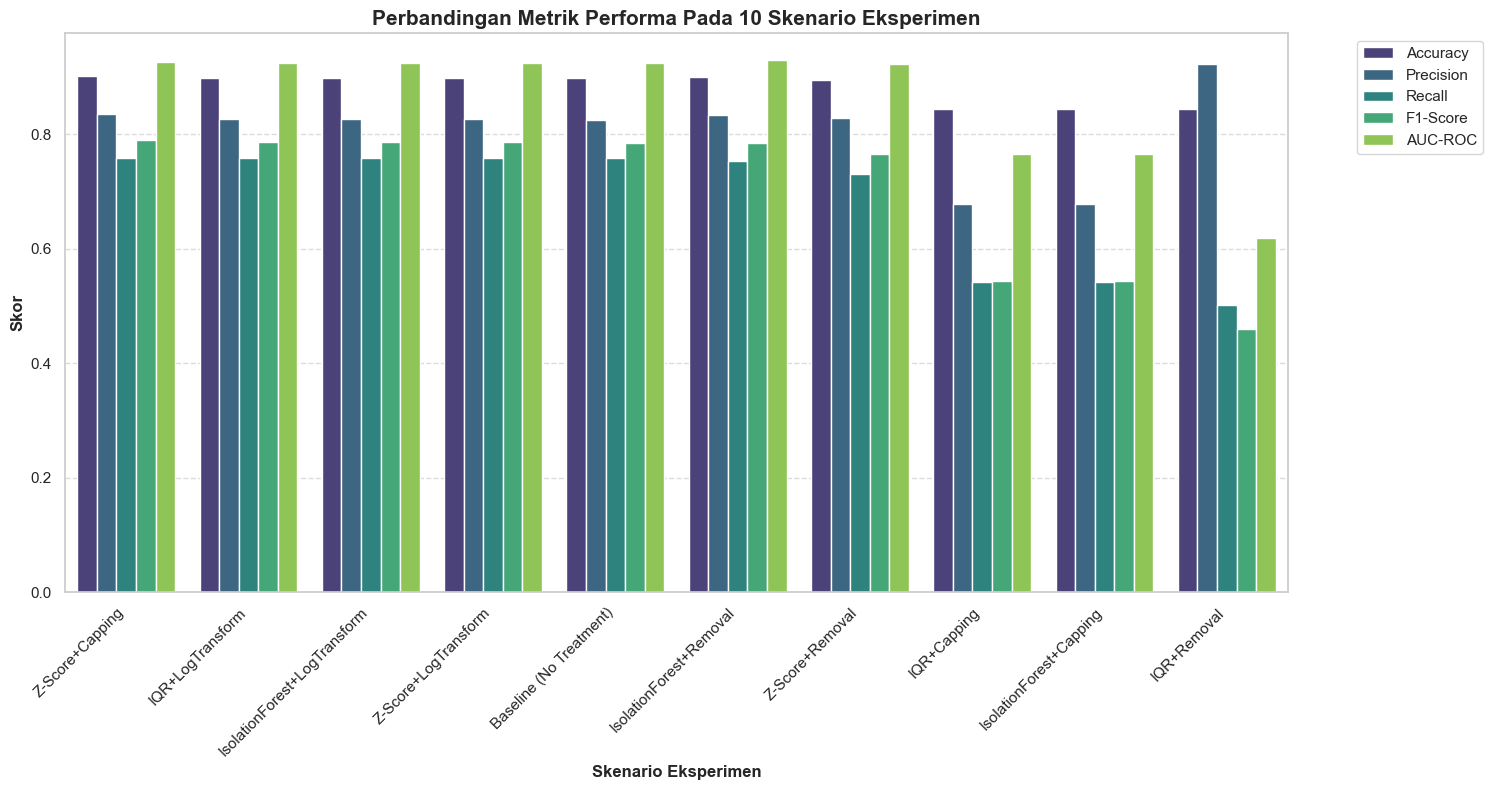

In [10]:
# ==========================================================
# 9. PERFORMANCE COMPARISON VISUALIZATIONS
# ==========================================================
plt.figure(figsize=(15, 8))

# Melt data to long-form for Seaborn plotting
df_plot = df_results.melt(id_vars='Skenario', var_name='Metrik', value_name='Skor')

# Bar Plot
sns.barplot(data=df_plot, x='Skenario', y='Skor', hue='Metrik', palette='viridis')

plt.title('Perbandingan Metrik Performa Pada 10 Skenario Eksperimen', fontweight='bold', fontsize=15)
plt.xlabel('Skenario Eksperimen', fontweight='bold')
plt.ylabel('Skor', fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

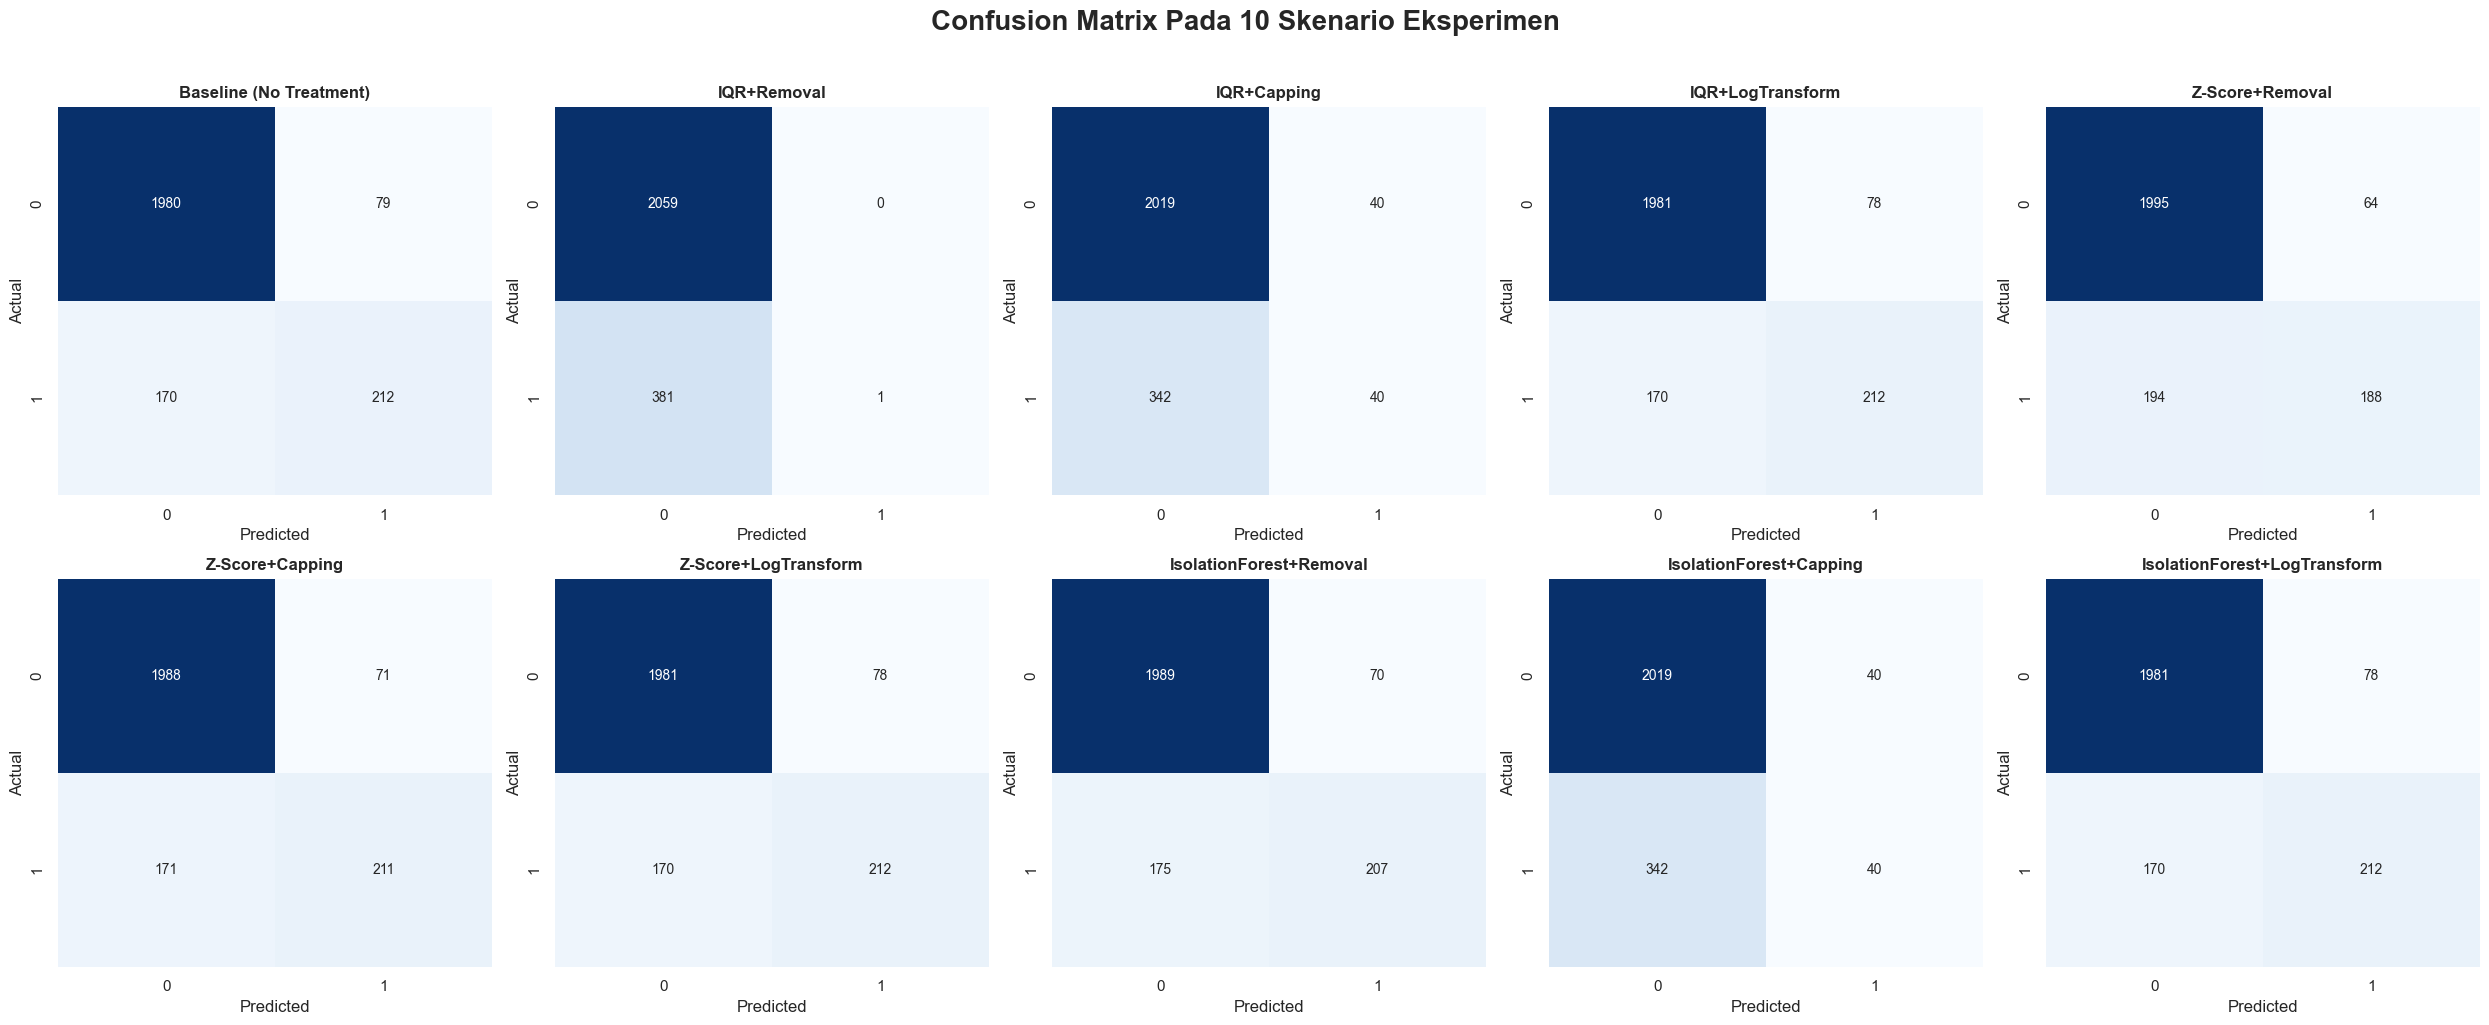

In [13]:
# ==========================================================
# 10. PLOTTING CONFUSION MATRICES FOR ALL 10 SCENARIOS
# ==========================================================
# Setup Figure 2 rows x 5 columns
fig, axes = plt.subplots(2, 5, figsize=(25, 10))
axes = axes.flatten()

# Baseline config
configs_for_cm = [('Baseline (No Treatment)', X_train, y_train)] + [(name, X_tr, y_tr) for name, (X_tr, y_tr) in scenarios.items()]

for i, (name, X_tr, y_tr) in enumerate(configs_for_cm):
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr)
    
    # Process test set on-the-fly
    X_te_processed = X_test.copy()
    if "LogTransform" in name:
        for col in num_cols:
            if (X_train[col] >= 0).all() and X_train[col].skew() > 0.5:
                X_te_processed[col] = np.log1p(X_test[col])
                
    X_te_sc = scaler.transform(X_te_processed)

    model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    model.fit(X_tr_sc, y_tr)

    y_pred = model.predict(X_te_sc)
    cm = confusion_matrix(y_test, y_pred)

    # Plot Heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(name, fontweight='bold', fontsize=12)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

plt.suptitle('Confusion Matrix Pada 10 Skenario Eksperimen', fontsize=20, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()